**Running on Colab?** Just run the setup cell below. It clones the repo and installs the package. For a free GPU: Runtime → Change runtime type → GPU.

In [1]:
# --- Colab setup (auto-injected by build_notebooks.py; do not edit the .ipynb) ---
import os, sys, subprocess

if "google.colab" in sys.modules and os.path.basename(os.getcwd()) != "tutorials":
    # Clone the repo (this also brings calibration.py and the data/ reference
    # files the notebooks load) and install the package.
    if not os.path.isdir("SRL"):
        url = "https://github.com/StructuralRL/SRL.git"
        subprocess.run(["git", "clone", "--depth=1", url, "SRL"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", "SRL"], check=True)
    # --no-deps: Colab already ships jax (with its matched GPU plugin), optax,
    # numpy, scipy, matplotlib, and tqdm. Installing our pinned jax here would
    # desync it from the preinstalled GPU plugin and crash GPU runtimes.
    # Import srl straight from the clone. A mid-session `pip install -e`
    # registers the package only through a .pth file that Python reads at
    # startup, so it does not take effect in the already-running Colab
    # kernel. Putting the repo root on sys.path makes `import srl` work now.
    sys.path.insert(0, os.path.abspath("SRL"))
    os.chdir("SRL/tutorials")
    sys.path.insert(0, os.getcwd())

# 4 — The Huggett economy

This is the first **general-equilibrium** notebook, and the first to use the
full logic of *structural reinforcement learning* (SRL). Through notebooks 0–3
the household faced a price it was *handed*: fixed in 0–2, an exogenous process
in 3. Now the price is **endogenous**: it is the bond price $q$ that clears the
market, and we have to go find it.

The paper's central idea shows up here in its simplest form. In a
heterogeneous-agent economy the true aggregate state is the whole
cross-sectional **distribution** $G(b,y)$. That object is infinite-dimensional,
and once you add aggregate risk it is the source of the "Master equation" curse.
But households don't care about the distribution directly. They care about it
only through the **price** it implies. SRL leans on this: it puts the
*low-dimensional price* in the agent's state in place of the distribution, and
clears markets *along the simulated path* instead of in an outer loop.

Here aggregate risk is off ($z \equiv 1$), so the equilibrium price is a single
stationary number and there is nothing to *learn* yet. But the machinery that
makes the hard case (notebook 5) work is exactly the machinery here:

1. the **wealth distribution** $\mathbf{g}$, the object we aggregate to clear
   the market (its first real job in the course);
2. **market clearing inside the environment**: the policy doubles as a demand
   curve, so there is no inner-loop/outer-loop iteration over the price;
3. **price-taking as a single `stop_gradient`**: the household optimizes
   *taking the equilibrium price as given*.

## What you should already know

- **Notebook 2**, the Structural Policy Gradient (SPG): the value vector
  $\mathbf{v}_\pi$, the transition matrix $\mathbf{A}_\pi$ we differentiate
  through, the scalar objective $\mathcal{L}=\mathbf{d}_0^{\mathsf T}\hat{\mathbf
  v}_\pi$, and the two distributions the solver carries (`m`, the population;
  `d`, the differentiable weight). We reuse `SPGSolver` unchanged and don't
  re-derive any of it. nb 4 only adds what's new in general equilibrium.
- **Notebook 3**, the household conditioning on an *exogenous* price process.
  The one move here is to make that price **endogenous**.
- A **stationary equilibrium** in a heterogeneous-agent model (Huggett 1993;
  Aiyagari 1994): a policy, a distribution, and a price that are mutually
  consistent.

Notebook 2 set one thing aside "for general equilibrium": the `stop_gradient`
inside the solver, which it called *price-taking*. **This is the notebook that
cashes that in.**

**References.** Yang, Wang, Schaab & Moll (2025), the SRL paper this package
implements; Huggett (1993); Aiyagari (1994); the reference solution we validate
against is the sequence-space Jacobian (SSJ) of Auclert, Bardóczy, Rognlie &
Straub (2021).

## The model

We use the paper's notation (Section 2). A continuum of individuals hold bonds
$b$ and receive idiosyncratic income $y$ (a Markov process); the individual
state is $s=(b,y)$. They choose consumption to maximize
$$\mathbb{E}_0\sum_{t=0}^\infty \beta^t u(c_t),\qquad u(c)=\frac{c^{1-\sigma}}{1-\sigma},$$
subject to the budget constraint and a borrowing limit
$$c_t + q_t\,b_{t+1} = b_t + y_t,\qquad b_{t+1}\ge \underline{b},$$
where $q_t$ is the **bond price** (the paper's eq. (2), with aggregate
productivity $z\equiv 1$ since there's no aggregate risk yet), and
$\underline{b}=0$ (no borrowing). As the paper notes, saving in bonds is
*equivalently* lending at a real gross return $1+r = 1/q$; our implementation
works in that return (it is what the reference solution reports) and we read off
the equilibrium as an interest rate $r$. Notebooks 0–2 *fixed* the price at
$q=0.995$ (`Q_FIXED`); here the market sets it.

**The distribution and its law of motion (from nb 2).** Discretize $s$ onto
$J=n_b\times n_y$ points. The cross-section is a vector $\mathbf{g}$, and a
policy $\pi$ induces the sparse $J\times J$ transition $\mathbf{A}_\pi$ with
$\mathbf{g}_{t+1}=\mathbf{A}_\pi^{\mathsf T}\mathbf{g}_t$. This $\mathbf{A}_\pi$
is the *structural knowledge* SPG differentiates through: the household knows
its own budget constraint and income process exactly, so in general equilibrium
the only thing left to *simulate* is the **price**. Here even that is a
stationary scalar.

**Equilibrium.** A stationary equilibrium is a policy $\pi=\{c(b,y),b'(b,y)\}$,
a distribution $\mathbf{g}$, and a bond price $q$ such that $\pi$ is optimal at
$q$, $\mathbf{g}$ is stationary under $\mathbf{A}_\pi$, and the **bond market
clears**:
$$D(q):=\int b'(b,y)\,dG(b,y) \;=\; B.$$
$D(q)$ is aggregate bond demand and $B$ is net supply. (Huggett's bonds are in
zero net supply, $B=0$; the stationary calibration we validate against uses a
positive level, $B=5.6$.)

## Market clearing happens *inside the environment*

Here is the move that makes this SRL rather than Aiyagari.

**Standard practice is two nested loops.** Guess a price. In an *inner loop*
solve the household problem and find its stationary distribution. In an *outer
loop* check whether the bond market clears, $D(q)=B$; if not, update the price
(bisection) and redo the entire inner solve. The household problem is re-solved
for every price guess.

**SRL has no outer loop.** As the paper puts it, *policy functions double as
individual demand schedules*: a candidate policy already says, at any price $q$,
how much each household wants to save, $b'(b,y;q)$. Integrating against the
current distribution gives aggregate demand $D(q)=\int b'\,dG$, and clearing is
then a one-line root-find for the $q$ with $D(q)=B$, solved *on the simulated
path, every step*. And recall (nb 2) that SPG is already simulating the
population $\mathbf{g}_t$ forward each gradient step, so the distribution it
needs is already in hand. Market clearing is treated as **part of the
environment** (agents interact with their environment under any policy, optimal
or not), so equilibrium prices are found even for suboptimal policies and the
price never needs an outer iteration. The library helper `find_clearing_point`
is that root-find.

## Price-taking is one `stop_gradient`

This is the idea notebook 2 set aside "for general equilibrium." The clearing
price depends on the policy (the policy *is* the demand curve), and so does the
objective, lifetime utility. So when we differentiate the objective to improve
the policy, the gradient could flow through two channels: the household's own
saving (what we want), and the household nudging the *equilibrium price* in its
favor (what a competitive, price-taking agent may not do).

The paper states the objective as: maximize $\mathbf{v}_\pi$ **taking as given
the evolution of equilibrium prices**, via the *stop-gradient operator*. A
price-taking household optimizes against the price but does not internalize its
effect on it; in the gradient, that means **cutting the gradient through price
formation**. In JAX that is `jax.lax.stop_gradient`, applied to the policy where
it feeds the clearing price (the visible line in `AUS_func` below), and
complemented by the solver detaching the population distribution `m` before it
sets the price (the line nb 2 pointed at). Together they *are* the
competitive-equilibrium assumption, in one operator. (Exercise 3 deletes it and
watches the answer distort.)

## Setup: the shared calibration and the SSJ reference

The household calibration is the one shared across the whole course
(`calibration.py`, as in notebooks 0–2): $\sigma=2$, $\beta=0.98$, the 3-state
Rouwenhorst income process ($E[y]=1$), and the double-exponential asset grid. We
validate against the **sequence-space Jacobian (SSJ)** reference solution
shipped in `data/ssj_huggett/`; because that reference uses the *same* income
process and asset spacing, the comparison is exactly like-for-like. The one
new, GE-specific parameter is the bond supply $B=5.6$ the price clears against.

In [2]:
import os
import inspect

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from calibration import SIGMA, BETA, rouwenhorst, asset_grid   # the shared spine (nb 0–2)
from srl import SPGSolver
from srl.utils.plotting import colors, create_subplots
from srl.utils.safe_linalg import (
    crra_util_func,
    find_clearing_point,
    interp_two_point_nonuniform,
)

# Paper-scale grids: the finer return grid pins the clearing rate precisely.
# This notebook is solved on GPU.
n_b, n_R = 200, 40

sigma, beta = SIGMA, BETA       # shared calibration; beta is the discount (the solver calls it gamma)
eps = 0.001                     # consumption floor
B = 5.6                         # net bond supply; the bond price clears the market at this level

# Income: the same Rouwenhorst process as notebooks 0–3.
_e, _Pi = rouwenhorst()
y_grid, y_trans = jnp.asarray(_e), jnp.asarray(_Pi)
n_y = y_grid.shape[0]

# Asset grid: the same double-exponential spacing (calibration.asset_grid). The
# SSJ reference is tabulated on N_REF = 200 points; we subsample to n_b (keeping
# both ends) so SPG and the reference live on a shared grid.
N_REF = 200
b_grid_full = jnp.asarray(asset_grid(N_REF))
sub_idx = jnp.linspace(0, N_REF - 1, n_b).astype(int)
b_grid = b_grid_full[sub_idx]

# Candidate gross returns R = 1 + r = 1/q. The market picks one from this grid
# each step; it brackets the equilibrium R ≈ 1.0056 (r ≈ 0.56%, q ≈ 0.994).
R_grid = jnp.linspace(0.95, 1.05, n_R)

_here = os.path.dirname(__file__) if "__file__" in globals() else "."
data_dir = os.path.join(_here, "data", "ssj_huggett")   # SSJ reference, for validation only

# Flattened (b, y) coordinates of the J = n_b * n_y states, used to build
# aggregate bond demand across the whole population at once.
b_flat = jnp.repeat(b_grid, n_y)                       # (J,)
y_flat = jnp.tile(y_grid, n_b)                         # (J,)

print(f"J = {n_b * n_y} states; B = {B}; sigma = {sigma}, beta = {beta}")
print("income states:", np.asarray(y_grid).round(3), " E[y] = 1")
print(f"gross-return grid R in [{float(R_grid.min()):.3f}, {float(R_grid.max()):.3f}]"
      f"  (r in [{float(R_grid.min()-1):.3%}, {float(R_grid.max()-1):.3%}],  q = 1/R)")

J = 600 states; B = 5.6; sigma = 2.0, beta = 0.98
income states: [0.436 0.885 1.794]  E[y] = 1
gross-return grid R in [0.950, 1.050]  (r in [-5.000%, 5.000%],  q = 1/R)


### The market-clearing helper, in full

`find_clearing_point` is the one piece of new machinery, and it's small. Given
aggregate demand `D` on the return grid, it finds the two adjacent grid points
that straddle the target supply `B` and hands back the interpolation weights.
That's the entire root-find, vectorized and differentiable-friendly, with no
Python loop. Here is the actual library source:

In [3]:
print(inspect.getsource(find_clearing_point))

@jax.jit
def find_clearing_point(B, Dt):
    """Find the two adjacent grid points on Dt straddling the target level B.

    Returns (lo_idx, hi_idx, w_lo, w_hi) such that
        B ≈ w_lo * Dt[lo_idx] + w_hi * Dt[hi_idx].
    Used inside `AUS_func` to clear the bond market at a price grid.
    """
    distances = jnp.abs(Dt - B)
    closest_idx = jnp.argmin(distances)
    closest_value = Dt[closest_idx]
    is_left = B < closest_value

    def left_case():
        i_hi = closest_idx
        left_mask = Dt < closest_value
        i_lo = jnp.argmin(jnp.where(left_mask, jnp.abs(Dt - B), jnp.inf))
        return i_lo, i_hi

    def right_case():
        i_lo = closest_idx
        right_mask = Dt > closest_value
        i_hi = jnp.argmin(jnp.where(right_mask, jnp.abs(Dt - B), jnp.inf))
        return i_lo, i_hi

    i_lo, i_hi = jax.lax.cond(is_left, left_case, right_case)
    i_lo, i_hi = jnp.minimum(i_lo, i_hi), jnp.maximum(i_lo, i_hi)

    Dt_lo = Dt[i_lo]
    Dt_hi = Dt[i_hi]
    denom 

## Model dynamics: clearing + price-taking, inside one step

`AUS_func` is the model's one-step map (notebook 2's interface). It returns the
sparse transition $\mathbf{A}_\pi$, the per-state utility vector $\mathbf{u}$,
and the next exogenous state. There is no aggregate state here (that's nb 5),
so the exogenous state is `None` and the whole economics is the market-clearing
computation. Read it in three parts, matching the three ideas above:

1. **Aggregate demand.** Each household's saving policy *is* its bond-demand
   curve; summing against the population $\mathbf{g}$ gives aggregate demand,
   evaluated across the grid of candidate prices (here in the return $R=1/q$).
2. **Clear.** `find_clearing_point(B, D)` returns the price at which $D(q)=B$.
3. **Price-taking.** Step 1 wraps the policy in `stop_gradient`, so the clearing
   price responds to the *level* of the policy while the gradient never flows
   back through price formation, and the household takes the price as given.

Everything after the cleared price is the ordinary household update from nb 2:
the budget constraint plus the interpolated $\mathbf{A}_\pi$ transition.

In [4]:
def reset_func(key):
    return None  # no exogenous aggregate state in the stationary economy


def AUS_func(policy, m, st, key):
    """One-step Huggett dynamics with the bond price cleared in-loop."""

    # --- price-taking: the policy feeds price formation with the gradient cut ---
    # (J, n_R) -> (n_R, J): the consumption share each household would choose at
    # each candidate return. stop_gradient => households do not internalize their
    # effect on the equilibrium price (the competitive-equilibrium assumption).
    cshare_by_R = jax.lax.stop_gradient(policy["cshare"]).reshape(-1, n_R).T

    # --- aggregate demand D(R) over the return grid ---
    wealth_by_R = jax.vmap(lambda R: b_flat * R + y_flat)(R_grid)        # (n_R, J)
    c_by_R = jnp.clip(wealth_by_R * cshare_by_R, eps, wealth_by_R - eps)
    demand = jnp.sum((wealth_by_R - c_by_R) * m, axis=-1)                # (n_R,)

    # --- clear: the R at which aggregate bond demand equals supply B ---
    i_lo, i_hi, w_lo, w_hi = find_clearing_point(B, demand)
    R = R_grid[i_lo] * w_lo + R_grid[i_hi] * w_hi
    lo, hi, wl, wh = interp_two_point_nonuniform(R, R_grid)  # policy index for R

    def build_triplets_for_state(idx_S):
        b_idx, y_idx = idx_S // n_y, idx_S % n_y
        b, y = b_grid[b_idx], y_grid[y_idx]
        # The household's share at the cleared return (interpolated between nodes).
        cshare = policy["cshare"][b_idx, y_idx, lo] * wl + policy["cshare"][b_idx, y_idx, hi] * wh
        wealth = R * b + y                                  # c + b' = R*b + y
        consumption = jnp.clip(wealth * cshare, eps, wealth - eps)
        utility = crra_util_func(consumption, sigma) * (1.0 - beta)
        b_next = wealth - consumption                       # next-period bonds, b' >= 0
        # Sparse transition: where b' lands on the grid x where income goes next.
        lo_b, hi_b, w_lo_b, w_hi_b = interp_two_point_nonuniform(b_next, b_grid)
        cols_lo = lo_b * n_y + jnp.arange(n_y, dtype=jnp.int32)
        cols_hi = hi_b * n_y + jnp.arange(n_y, dtype=jnp.int32)
        rows = jnp.full((2 * n_y,), idx_S, dtype=jnp.int32)
        cols = jnp.concatenate([cols_lo, cols_hi])
        vals = jnp.concatenate([w_lo_b * y_trans[y_idx], w_hi_b * y_trans[y_idx]])
        return (rows, cols, vals), utility

    J = n_b * n_y
    A, U = jax.vmap(build_triplets_for_state)(jnp.arange(J, dtype=jnp.int32))
    return A, U, None


state_space = {"b": ("markov", n_b), "y": ("markov", n_y), "R": ("non-markov", n_R)}
action_space = {"cshare": (0.0001, 0.9999, 0.5)}

## Solve with SPG

Same solver, same call as notebook 2. Only the environment changed. The policy
is a consumption share over $(b, y, R)$; we ascend simulated lifetime utility.

Two settings are scaled up from the household notebooks for a *paper-clean*
general-equilibrium figure. SPG is a stochastic method: it learns the policy by
simulating paths, so states the economy rarely visits (here, high wealth) get a
noisier gradient and converge last. We average over more simulated paths
(`sample_size=64`) to cut that gradient variance, and run more steps
(`epoch=1000`) so even the rarely-visited states settle. The result matches the
reference across the whole ergodic support, not just where mass is densest.

In [5]:
spg_solver = SPGSolver(sample_size=256, early_stop=False, epoch=2000, trunc_eps=1e-4)
spg_policy, logs = spg_solver.solve(beta, state_space, action_space, AUS_func, reset_func)
print(f"SPG done: {len(logs)} iterations, {spg_solver.total_time:.1f}s, "
      f"final max policy change {logs[-1]['max_l1_err']:.2E}")

trunc_T=456
['cshare.shape = (200, 3, 40)'] J = 600


100%|██████████| 2000/2000 [06:15<00:00,  5.32it/s, max_l1_err=3.493E-05, time(sec)=373.402, cum(EU)=-0.0956]

SPG done: 2000 iterations, 373.4s, final max policy change 3.49E-05


## Check 1: the consumption policy matches the reference

To make us feel confident in this solution, we compare it against a reference
solution method that you have probably worked through yourself: the SSJ repo of
Auclert et al. We evaluate the SPG policy at the reference equilibrium return
and lay it over the SSJ consumption policy, one panel per income state.

We plot over the **wealth range where households actually live**, up to the 99th
percentile of the stationary distribution the solver simulated. There's a reason
for this. The policy gradient learns by *visiting* states, so the far-wealth
tail (the top ~1% of households, who rarely save that much) barely gets trained
and stays a bit ragged. That region carries almost no mass and does no economic
work, and Check 2's distribution makes that plain. On the support that matters,
SPG and the reference sit right on top of each other. (This is how the paper
plots its policy figures too.)

SSJ reference equilibrium: r = 0.5621%  (R = 1.00562,  q = 1/R = 0.99441)


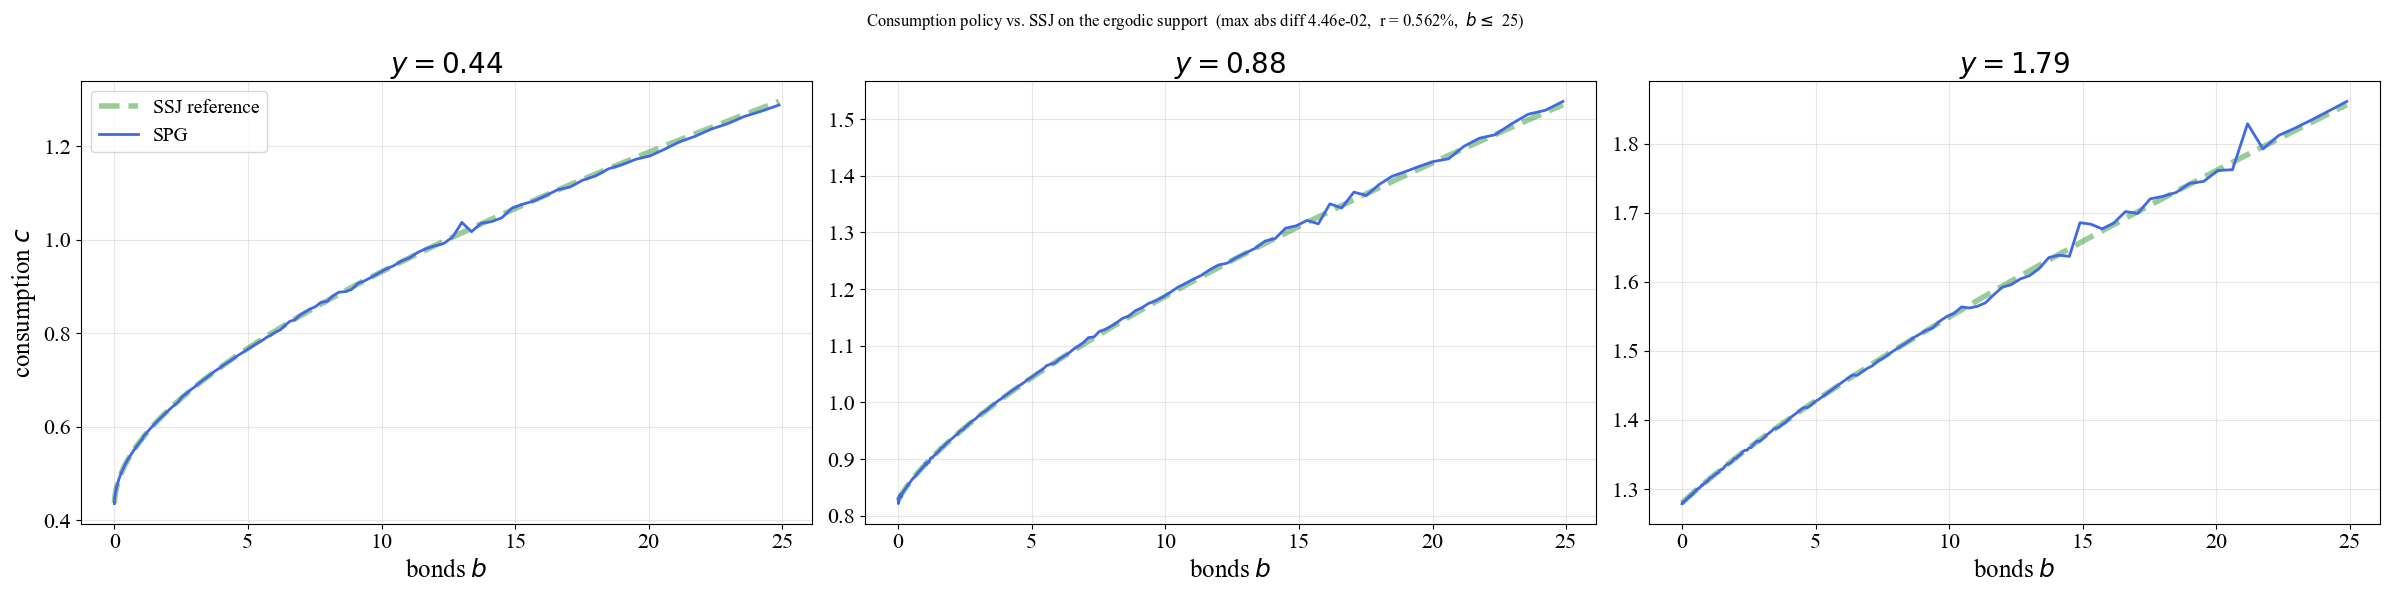

max |c_SPG - c_SSJ| on the ergodic support (b <= 24.9) = 4.46e-02


In [ ]:
ssj_savings = jnp.asarray(np.load(f"{data_dir}/savings.npy"))
ssj_prices_raw = np.load(f"{data_dir}/prices.npy", allow_pickle=True)
ssj_r, ssj_w = float(ssj_prices_raw[0]), float(ssj_prices_raw[1])
ssj_dist = jnp.asarray(np.load(f"{data_dir}/distribution.npy"))
print(f"SSJ reference equilibrium: r = {ssj_r:.4%}  (R = {1 + ssj_r:.5f},  q = 1/R = {1/(1+ssj_r):.5f})")

# The ergodic support: wealth up to the 99th percentile of the simulated
# stationary distribution (the marginal of spg_solver.m0 over bonds).
m_b = np.asarray(spg_solver.m0.mean(0)).reshape(n_b, n_y).sum(axis=1)
b_cut = float(b_grid[int(np.searchsorted(np.cumsum(m_b / m_b.sum()), 0.99))])
on_support = np.asarray(b_grid) <= b_cut

lo, hi, w_lo, w_hi = interp_two_point_nonuniform(1 + ssj_r, R_grid)
max_abs = 0.0
fig, axs = create_subplots(1, n_y)
for i in range(n_y):
    cshare = spg_policy["cshare"][:, i, lo] * w_lo + spg_policy["cshare"][:, i, hi] * w_hi
    wealth = (1 + ssj_r) * b_grid + y_grid[i]
    c_spg = jnp.clip(cshare * wealth, eps, wealth - eps)
    # SSJ consumption = resources - savings, on the same subsampled grid.
    c_ssj = (1 + ssj_r) * b_grid + ssj_w * y_grid[i] - ssj_savings[i][sub_idx]
    # Measure and plot only on the ergodic support (see the note above).
    max_abs = max(max_abs, float(jnp.max(jnp.abs(c_spg - c_ssj)[on_support])))
    ax = axs[0][i]
    ax.plot(b_grid[on_support], c_ssj[on_support], ls="--", lw=4, alpha=0.4,
            color=colors[1], label="SSJ reference")
    ax.plot(b_grid[on_support], c_spg[on_support], lw=2, color=colors[0], label="SPG")
    ax.set_title(f"$y = {float(y_grid[i]):.2f}$")
    ax.set_xlabel("bonds $b$")
    if i == 0:
        ax.set_ylabel("consumption $c$")
        ax.legend()
    ax.grid(alpha=0.3)
fig.suptitle(f"Consumption policy vs. SSJ on the ergodic support  "
             f"(max abs diff {max_abs:.2e},  r = {ssj_r:.3%},  $b \\leq$ {b_cut:.0f})")
fig.tight_layout()
plt.show()
print(f"max |c_SPG - c_SSJ| on the ergodic support (b <= {b_cut:.1f}) = {max_abs:.2e}")

## Check 2: the wealth distribution

This is the new object, and a good moment to look at it. In general equilibrium
the distribution does real work: it's the weight that turns the policy into
aggregate demand. SPG carries the population distribution as it simulates, so we
get it for free from the converged solver (`spg_solver.m0`, averaged over the
simulated paths). We compare it, income state by income state, to the SSJ
stationary distribution.

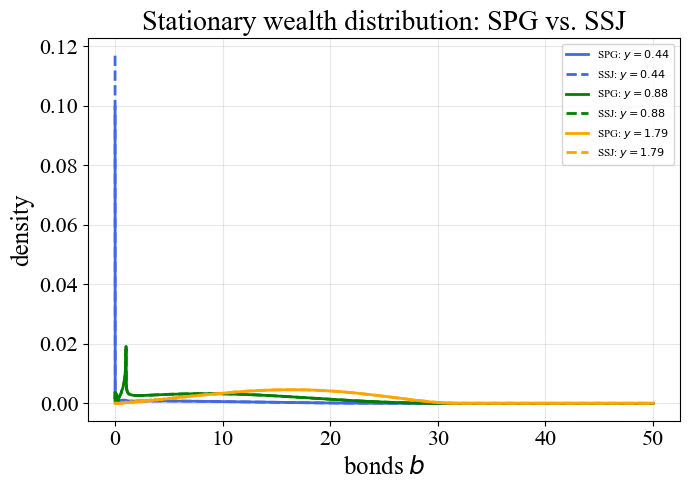

In [7]:
m_ergodic = spg_solver.m0.mean(0)                       # (J,) average over paths
m_ergodic = m_ergodic / m_ergodic.sum()
m_by_state = m_ergodic.reshape(n_b, n_y)

fig, ax = plt.subplots(figsize=(7, 5))
for i in range(n_y):
    ax.plot(b_grid, m_by_state[:, i], lw=2, color=colors[i],
            label=f"SPG: $y = {float(y_grid[i]):.2f}$")
    ssj_d = ssj_dist[i][sub_idx]
    ssj_d = ssj_d / ssj_d.sum() * float(m_by_state[:, i].sum())  # match marginal mass
    ax.plot(b_grid, ssj_d, ls="--", lw=2, color=colors[i],
            label=f"SSJ: $y = {float(y_grid[i]):.2f}$")
ax.set_xlabel("bonds $b$")
ax.set_ylabel("density")
ax.set_title("Stationary wealth distribution: SPG vs. SSJ")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Check 3: the market actually clears

The model-specific diagnostic: **excess demand crosses zero at the equilibrium
return.** Using the converged policy and the stationary distribution, we sweep
the return grid and plot aggregate bond demand minus supply, $D(R) - B$. The
crossing is the price the solver found, and it should sit on the SSJ
equilibrium $r$.

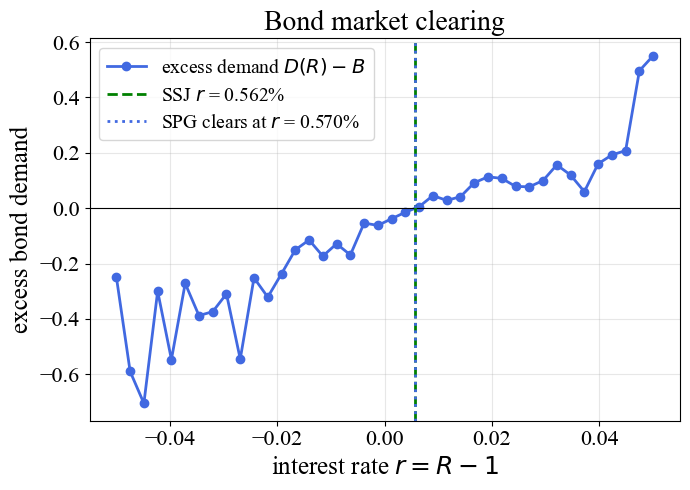

SPG clearing r = 0.5700%   vs   SSJ r = 0.5621%


In [8]:
cshare_by_R = spg_policy["cshare"].reshape(-1, n_R).T            # (n_R, J)
wealth_by_R = jax.vmap(lambda R: b_flat * R + y_flat)(R_grid)
c_by_R = jnp.clip(wealth_by_R * cshare_by_R, eps, wealth_by_R - eps)
excess = jnp.sum((wealth_by_R - c_by_R) * m_ergodic, axis=-1) - B  # D(R) - B

# Interpolate the zero-crossing return for reporting.
i_lo, i_hi, w_lo, w_hi = find_clearing_point(B, excess + B)
R_clear = float(R_grid[i_lo] * w_lo + R_grid[i_hi] * w_hi)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(R_grid - 1, excess, "o-", lw=2, color=colors[0], label="excess demand $D(R)-B$")
ax.axhline(0, color="k", lw=0.8)
ax.axvline(ssj_r, color=colors[1], ls="--", lw=2, label=f"SSJ $r$ = {ssj_r:.3%}")
ax.axvline(R_clear - 1, color=colors[0], ls=":", lw=2, label=f"SPG clears at $r$ = {R_clear-1:.3%}")
ax.set_xlabel("interest rate $r = R - 1$")
ax.set_ylabel("excess bond demand")
ax.set_title("Bond market clearing")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"SPG clearing r = {R_clear - 1:.4%}   vs   SSJ r = {ssj_r:.4%}")

## What we did, and what's next

We solved a Huggett economy in general equilibrium: the bond price is no longer
handed to the household but **discovered by market clearing**, and the SPG
policy, the stationary distribution, and the clearing rate all match the SSJ
reference. Two ideas did the work. The distribution $\mathbf{g}$ is the
aggregator behind $D(q)$, and **`stop_gradient` is price-taking**. And the
solver never grew an outer loop: clearing happens *inside the environment*.

**Notebook 5** is where the payoff comes, and the reason SRL exists: an
*aggregate* productivity shock $z_t$. Then the equilibrium price is a process
$q_t = P^*(\mathbf{g}_t, z_t)$, and the paper's key difficulty bites. While
$(\mathbf{g}_t, z_t)$ is Markov, the low-dimensional $q_t$ is **not**, so you
can't even write a Bellman equation in $(s,q,z)$. That's the "Master equation"
curse, with the whole distribution as a state. SRL sidesteps it by keeping the
**low-dimensional price** in the agent's state in place of the distribution and
letting the agent *learn the price process from simulated paths*, a restricted
perceptions equilibrium. It's exactly the machinery of this notebook, with the
stationary scalar $q$ promoted to a process.

## Exercises

1. **Bond supply and the interest rate.** Re-solve with a larger bond supply
   $B$. More bonds to be held in equilibrium requires a more attractive return,
   so the clearing $r$ should *rise*. A worked solution is below.
2. **Patience.** Raise $\beta$ (more patient households save more at any given
   return), then re-solve. Predict the direction of the clearing $r$ before you
   run it, then check. *(Hint: stronger saving desire ⇒ excess demand at the old
   price ⇒ the return must fall to clear.)*
3. **Why price-taking is `stop_gradient` (stretch).** Delete the
   `jax.lax.stop_gradient` in `AUS_func` and re-solve. Now the gradient flows
   through the price-formation channel: the "household" learns it can move the
   equilibrium return in its own favor, which is exactly what a competitive
   price-taker may not do. Compare the resulting policy and clearing $r$ to the
   reference and explain the distortion. This is the one-line competitive
   assumption, made visible by its absence.

### Worked solution: Exercise 1 (bond supply)

We rebuild the dynamics with a larger $B$ and re-solve. (The only change is the
supply level the market clears against.) The clearing $r$ moves up.

In [9]:
def solve_for_B(B_value, epoch=1000):
    def AUS_B(policy, m, st, key):
        cshare_by_R = jax.lax.stop_gradient(policy["cshare"]).reshape(-1, n_R).T
        wealth_by_R = jax.vmap(lambda R: b_flat * R + y_flat)(R_grid)
        c_by_R = jnp.clip(wealth_by_R * cshare_by_R, eps, wealth_by_R - eps)
        demand = jnp.sum((wealth_by_R - c_by_R) * m, axis=-1)
        i_lo, i_hi, w_lo, w_hi = find_clearing_point(B_value, demand)
        R = R_grid[i_lo] * w_lo + R_grid[i_hi] * w_hi
        lo, hi, wl, wh = interp_two_point_nonuniform(R, R_grid)

        def build(idx_S):
            b_idx, y_idx = idx_S // n_y, idx_S % n_y
            b, y = b_grid[b_idx], y_grid[y_idx]
            cshare = policy["cshare"][b_idx, y_idx, lo] * wl + policy["cshare"][b_idx, y_idx, hi] * wh
            wealth = R * b + y
            c = jnp.clip(wealth * cshare, eps, wealth - eps)
            u = crra_util_func(c, sigma) * (1.0 - beta)
            b_next = wealth - c
            lo_b, hi_b, w_lo_b, w_hi_b = interp_two_point_nonuniform(b_next, b_grid)
            cols = jnp.concatenate([lo_b * n_y + jnp.arange(n_y, dtype=jnp.int32),
                                    hi_b * n_y + jnp.arange(n_y, dtype=jnp.int32)])
            rows = jnp.full((2 * n_y,), idx_S, dtype=jnp.int32)
            vals = jnp.concatenate([w_lo_b * y_trans[y_idx], w_hi_b * y_trans[y_idx]])
            return (rows, cols, vals), u

        A, U = jax.vmap(build)(jnp.arange(n_b * n_y, dtype=jnp.int32))
        return A, U, None

    solver = SPGSolver(sample_size=64, early_stop=False, epoch=epoch, trunc_eps=0.001, verbose=False)
    pol, _ = solver.solve(beta, state_space, action_space, AUS_B, reset_func)
    m = solver.m0.mean(0); m = m / m.sum()
    cby = pol["cshare"].reshape(-1, n_R).T
    wby = jax.vmap(lambda R: b_flat * R + y_flat)(R_grid)
    cc = jnp.clip(wby * cby, eps, wby - eps)
    i_lo, i_hi, w_lo, w_hi = find_clearing_point(B_value, jnp.sum((wby - cc) * m, axis=-1))
    return float(R_grid[i_lo] * w_lo + R_grid[i_hi] * w_hi) - 1.0


B_high = 8.0
r_base = solve_for_B(B)
r_high = solve_for_B(B_high)
print(f"B = {B}: clearing r = {r_base:.4%}")
print(f"B = {B_high}: clearing r = {r_high:.4%}")
print("higher bond supply -> higher equilibrium r" if r_high > r_base else "unexpected: r did not rise")

  0%|          | 0/1000 [00:00<?, ?it/s]

 50%|████▉     | 497/1000 [00:49<00:50,  9.99it/s, max_l1_err=1.525E-04, time(sec)=49.211, cum(EU)=-0.0952]


KeyboardInterrupt: 